### 1、基于RODM模型开展风浪耦合模型研究。考虑波浪谱和API风谱
### 2、该模型是风浪耦合工作1的进一步拓展工作。

In [1]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP

### 经典水弹性计算波浪问题

In [2]:
# setting initial parameter, reading mass and stiffness matrix
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
master_nodes_length = len(master_nodes)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\wind_stduy\BM10_direaction0_full200.nc"))
omega = dataset.omega.values
omega_number = np.arange(0,199,1)

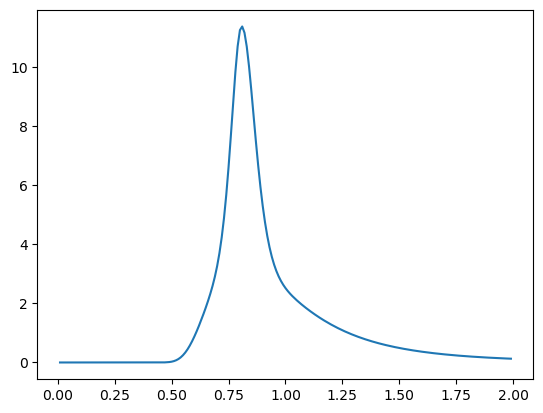

In [3]:
# 引入波浪谱
import wave_spectrum as ws
Hs = 2.75
Tp = 7.78
df = 0.01 # frequency resolution
S_wave = ws.jonswap(Hs, Tp, omega)
plt.plot(omega,S_wave)

In [4]:
# 引入载荷反转矩阵
def reverse_load_matrix(load_matrix, num_dofs=5):
    """
    反转载荷矩阵的节点加载顺序。

    参数：
    load_matrix: numpy.ndarray，大小为 (1, N) 的载荷矩阵，其中 N 是节点数乘以每节点的自由度数。
    num_dofs: int，每个节点的自由度数，默认值为 5。

    返回值：
    reversed_load_matrix: numpy.ndarray，反转节点加载顺序后的载荷矩阵。
    """
    # 确定节点数量
    num_nodes = load_matrix.shape[1] // num_dofs

    # 将矩阵按每 5 个元素分成子矩阵
    submatrices = np.split(load_matrix, num_nodes, axis=1)

    # 反转子矩阵的顺序
    reversed_submatrices = submatrices[::-1]

    # 重新组合成一个新的矩阵
    reversed_load_matrix = np.hstack(reversed_submatrices)

    return reversed_load_matrix

In [9]:
# 引入风载荷
import DM_Windload as DM_Wind
wind_speed = 30
distance = 30
wind_direction = 0 # 风向角
windload_cd_file = f"E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cd_degree{wind_direction}.txt"
windload_cl_file = f"E:\phd\Code\DM-FEM2D\winddata\Ti0.1_cl_degree{wind_direction}.txt"
windload_cd = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=31, total_cols=151, file_path=windload_cd_file,wind_direction = wind_direction)
windload_cl = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=31, total_cols=151, file_path=windload_cl_file,wind_direction = wind_direction)
windload_cd_damping = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=13, total_cols=61, file_path=windload_cd_file,wind_direction = wind_direction)
windload_cl_damping = DM_Wind.WindLoad(U10=wind_speed, z=2, total_rows=13, total_cols=61, file_path=windload_cl_file,wind_direction = wind_direction)
# 计算风产生的阻尼效应feng
Wind_Damping = (windload_cd_damping.compute_wind_damping(dof=0) + 
                windload_cl_damping.compute_wind_damping(dof=2) + 
                windload_cd_damping.compute_wind_damping(dof=4))*5.9 # 5.9是转化系数多节点到少节点
Wind_Damping = SEREP.reduce_dofs(Wind_Damping,num_nodes,[5])
# 形成集中风载荷
cd_sums,cd_submodules = windload_cd.wind_coefficient_lumped()
cl_sums,cl_submodules = windload_cl.wind_coefficient_lumped()


In [10]:
Area = 5*5
nodes_per_row = 61
# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
# node displacement
displacement = []
F_wave = []
mass_full = []
damping_full = []
stiffness_full = []
for i in omega_number:
    # print("计算进展：",i/39)
    # wind load    omega
    wind_load = windload_cd.wind_force_lumped(target_frequency=omega[i],distance=distance,cd_sums=cd_sums,cl_sums=cl_sums,cl_submodules=cl_submodules)
    # read hydrodynamic data
    added_mass = dataset['added_mass'][i].values
    radiation_damping = dataset['radiation_damping'][i].values
    inertia_matrix = dataset['inertia_matrix'].values
    # hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values
    # consider wave spectrum
    F_w = F_w * np.sqrt(S_wave[i]*df)
    # REDUCE THE MATRICES
    added_mass = SEREP.reduce_dofs(added_mass,master_nodes_length,[5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping,master_nodes_length,[5])
    # hyrostatic stiffness or fem spring stiffness
    # 1. choice hydrostatic stiffness
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,master_nodes_length,[5])

    inertia_matrix = SEREP.reduce_dofs(inertia_matrix,master_nodes_length,[5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, master_nodes_length, 5).reshape(1,5*master_nodes_length)

    # Generate the system matrices
    mass = added_mass + MR
    damping = radiation_damping + T.T@Wind_Damping@T
    stiffness =  hydrostatic_stiffness + KR
    # F_w = reverse_load_matrix(F_w, num_dofs=5)
    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w+wind_load, omega[i])
    # Restore global displacement under disorder masterdofs and slavedofs
    global_displacement_disorder = T @ master_displacement
    # Reorder global displacement under order
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
    # 保存数据
    mid = global_displacement[2::5,:]
    displacement.append(mid)
    F_wave.append(F_w)
    mass_full.append(mass)
    damping_full.append(damping)
    stiffness_full.append(stiffness)
    

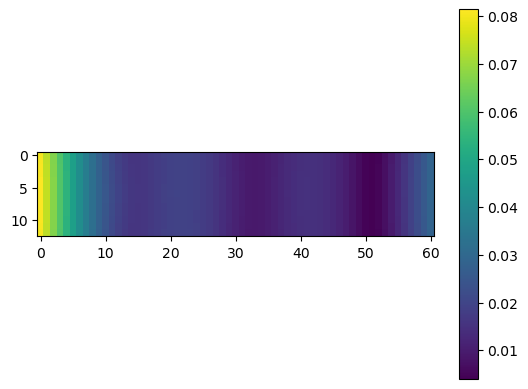

In [11]:
displacement = np.array(displacement).reshape(199,13,61)
plt.imshow(abs(displacement[100,:,:]))
plt.colorbar()

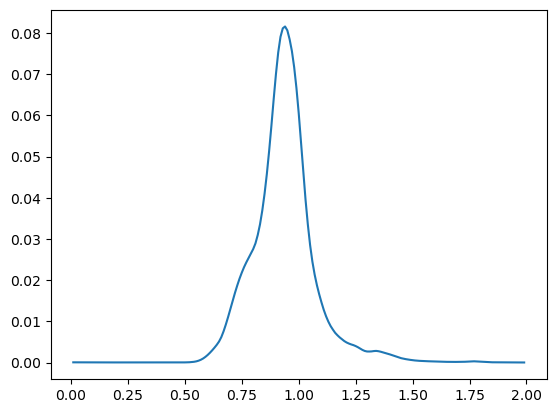

In [8]:
mean_displacement = np.mean(abs(displacement.reshape(199,793)),axis=1)
plt.plot(omega,(mean_displacement**2/0.01))

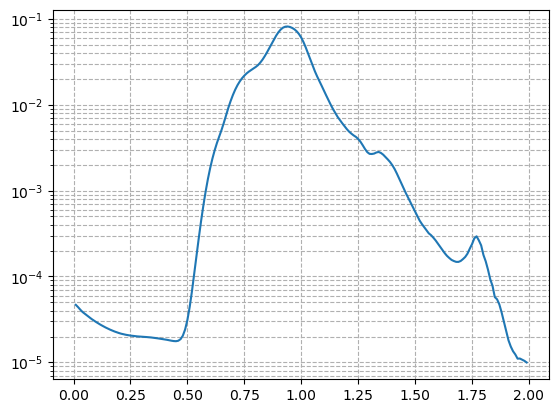

In [9]:
mean_displacement = np.mean(abs(displacement.reshape(199,793)), axis=1)
# first_displacement = np.mean(np.abs(wind_displacement[:,0:5]), axis=1)
plt.plot(omega,(mean_displacement**2/0.01))
# plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--")

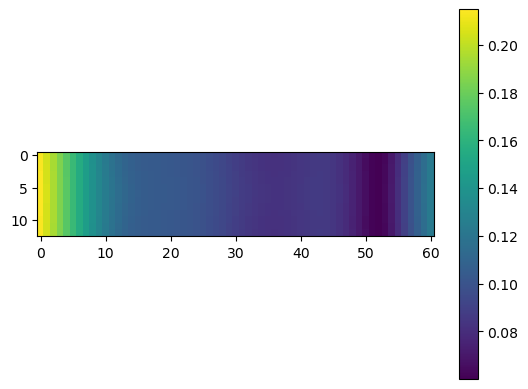

In [10]:
wind_displacement_df = np.abs(displacement.reshape(199,793))*0.01
# 求每一列的和
wind_displacement_sum = np.sum(wind_displacement_df, axis=0)
wind_displacement_root_mean_square = wind_displacement_sum.reshape(13, 61)
plt.imshow(np.sqrt(wind_displacement_root_mean_square))
plt.colorbar()

In [12]:
# 得到波浪导致的运动响应
displacement = np.array(displacement).reshape(199,793)
average_heave_displacement = np.mean(abs(displacement), axis=1)

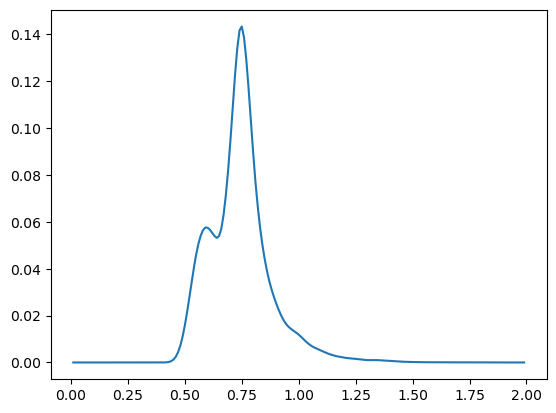

In [13]:
# 计算响应谱
response_spectrum = average_heave_displacement ** 2 * S_wave
plt.plot(omega, response_spectrum)

In [5]:
df_displacement = abs(displacement)**2*S.reshape(40,1)*0.05
sum_displacement = np.sum(df_displacement, axis=0)
plt.imshow(np.sqrt(sum_displacement.reshape(13,61)))
plt.colorbar()

TypeError: bad operand type for abs(): 'list'

In [41]:
df_response = response_spectrum*0.05

In [ ]:
np.savetxt('wave_response_spectrum.txt', response_spectrum)

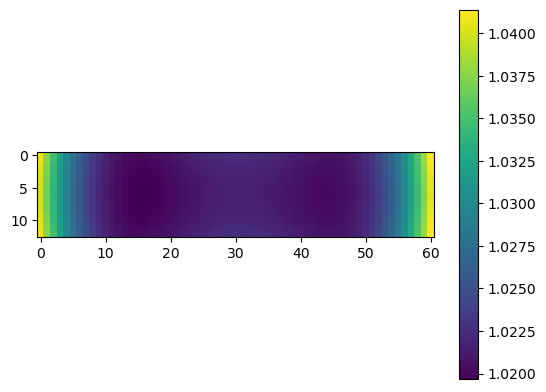

In [6]:
displacement = np.array(displacement).reshape(40,13,61)
plt.imshow(abs(displacement[0,:,:]))
plt.colorbar()

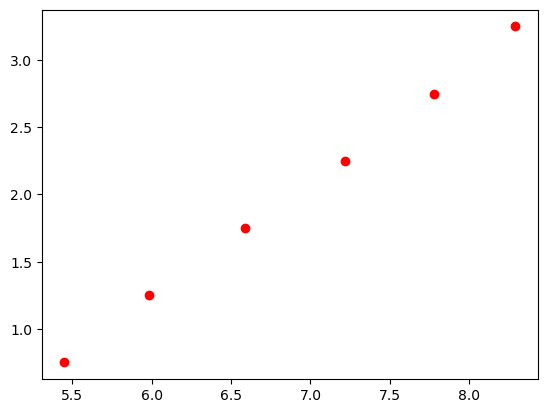

In [16]:
x = [5.45, 5.98, 6.59, 7.22, 7.78, 8.29]
y = [0.75, 1.25, 1.75, 2.25, 2.75, 3.25]
plt.plot(x, y, 'ro')

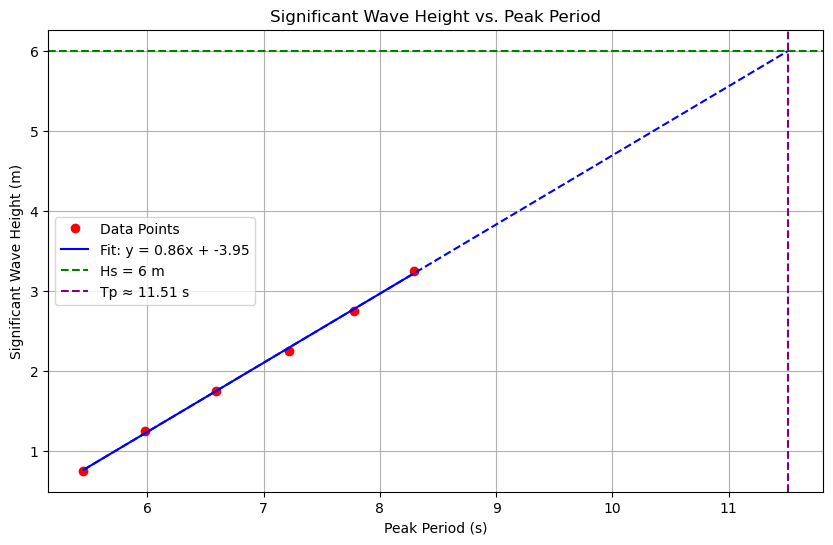

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 提供的数据
x = np.array([5.45, 5.98, 6.59, 7.22, 7.78, 8.29])  # 谱峰周期
y = np.array([0.75, 1.25, 1.75, 2.25, 2.75, 3.25])  # 有义波高

# 拟合函数，假设为线性关系
def linear_fit(x, a, b):
    return a * x + b

# 进行线性拟合
params, _ = curve_fit(linear_fit, x, y)

# 使用拟合参数进行预测
a, b = params
predicted_hs = 6  # 有义波高为6米
predicted_tp = 11.51  # 谱峰周期为11.51秒

# 绘制数据点和拟合曲线
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='Data Points')
plt.plot(x, linear_fit(x, *params), 'b-', label=f'Fit: y = {a:.2f}x + {b:.2f}')
plt.xlabel('Peak Period (s)')
plt.ylabel('Significant Wave Height (m)')
plt.title('Significant Wave Height vs. Peak Period')
plt.axhline(y=predicted_hs, color='g', linestyle='--', label=f'Hs = {predicted_hs} m')
plt.axvline(x=predicted_tp, color='purple', linestyle='--', label=f'Tp ≈ {predicted_tp} s')
plt.legend()
plt.grid(True)

# 将拟合线延伸到(11.51, 6)
extended_x = np.linspace(min(x), predicted_tp, 500)
plt.plot(extended_x, linear_fit(extended_x, *params), 'b--')

plt.show()


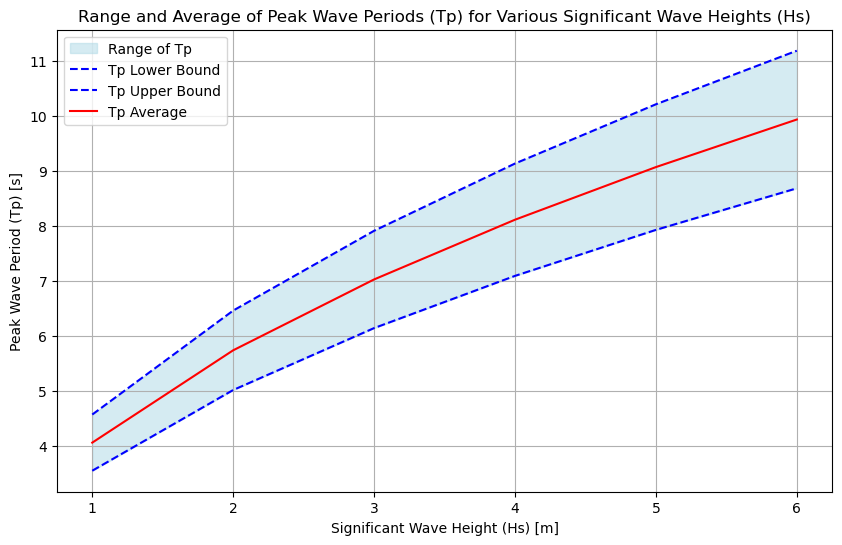

Hs [1. 2. 3. 4. 5. 6.]
Tp [ 4.56563863  6.45678807  7.90791807  9.13127725 10.20907833 11.18348498]


In [15]:
# 通过有义波高来计算谱峰周期，采用Ti et al.等人论文中的公式
import numpy as np
import matplotlib.pyplot as plt

# 定义重力加速度
g = 9.81  # m/s^2

# 定义有义波高 (Hs) 数组，从0到6米
Hs_values = np.linspace(1, 6, 6)  # 使用100个点来更平滑地展示曲线

# 计算谱峰周期 (Tp) 的上下限和平均值
Tp_lower = 11.1 * np.sqrt(Hs_values / g)
Tp_upper = 14.3 * np.sqrt(Hs_values / g)
Tp_average = 12.7 * np.sqrt(Hs_values / g)

# 绘图
plt.figure(figsize=(10, 6))
plt.fill_between(Hs_values, Tp_lower, Tp_upper, color='lightblue', alpha=0.5, label='Range of Tp')
plt.plot(Hs_values, Tp_lower, 'b--', label='Tp Lower Bound')
plt.plot(Hs_values, Tp_upper, 'b--', label='Tp Upper Bound')
plt.plot(Hs_values, Tp_average, 'r-', label='Tp Average')

plt.title('Range and Average of Peak Wave Periods (Tp) for Various Significant Wave Heights (Hs)')
plt.xlabel('Significant Wave Height (Hs) [m]')
plt.ylabel('Peak Wave Period (Tp) [s]')
plt.legend()
plt.grid(True)
plt.show()
print("Hs",Hs_values)
print("Tp",Tp_upper)

### 上述为计算RAO，下面为引入波浪载荷谱

In [ ]:
# define jonswap wave spectrum
def jonswap(Hs, Tp, gamma, omega):
    '''
        Hs: significant wave height
        Tp: peak period
        gamma: peak enhancement factor
        omega: 角频率
        jonswap wave spectrum, refrerence:
        https://www.sciencedirect.com/science/article/pii/S0960148116301446
        omega=2*pi*f, f为频率, omega为角频率,最终结果需要乘以2*pi
        以与论文结果对比验证
    '''
    fp = 2*np.pi/Tp
    # if omega.all() < fp:
    #     sigma = 0.07
    # else:
    #     sigma = 0.09
    sigma = np.where(omega <= fp, 0.07, 0.09)
    alpha = 0.0624 / (0.230 + 0.0336 * gamma - (0.185 / (1.9+gamma)))
    beta = np.exp(-(omega-fp)**2/(2*(sigma**2)*(fp**2)))
    return alpha*Hs**2*fp**4*omega**(-5)*gamma**beta*np.exp(-1.25*(fp/omega)**4)*2*np.pi # 乘以2*pi是为了与论文结果对比验证

# wave spectrum
Hs = 3.25
Tp = 8.29
gamma = 3.3
omega = np.linspace(0.1, 2, 40)
S = jonswap(Hs, Tp, gamma, omega)
plt.plot(omega, S)

In [ ]:
plt.plot((2*np.pi)/omega,average_heave_displacement)

In [ ]:
# 计算响应谱
response_spectrum = average_heave_displacement ** 2 * S
plt.plot(omega, response_spectrum)

### 单独风载荷计算